In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

In [ ]:
train_path="/content/drive/MyDrive/dataset/cats_dogs/train"
test_path="/content/drive/MyDrive/dataset/cats_dogs/val"

In [ ]:
img_size = (150, 150)   # Or (224, 224) for models like ResNet
batch_size = 32

In [ ]:
# Initialize ImageDataGenerator with normalization
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
# Load training data
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 275 images belonging to 2 classes.


In [ ]:
val_generator = datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 70 images belonging to 2 classes.


In [ ]:
# Load VGG16 base model (no top layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
# Freeze all VGG16 layers
base_model.trainable = True

set_trainable = False

for layer in base_model.layers:
  if layer.name == "block5_conv1":
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

model = Model(inputs=base_model.input, outputs=base_model.output)

In [ ]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
train_generator.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
# Extract features
train_features = model.predict(train_generator, verbose=1)
val_features = model.predict(val_generator, verbose=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 79s 8s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step


In [ ]:
# Get the labels
train_labels = train_generator.classes
val_labels = val_generator.classes

In [ ]:
train_features.shape

(275, 4, 4, 512)

In [ ]:
val_features.shape

(70, 4, 4, 512)

In [ ]:
# Flatten the 3D feature maps to 2D vectors
train_features_flat = train_features.reshape((train_features.shape[0], -1))
val_features_flat = val_features.reshape((val_features.shape[0], -1))

In [ ]:
train_features_flat.shape

(275, 8192)

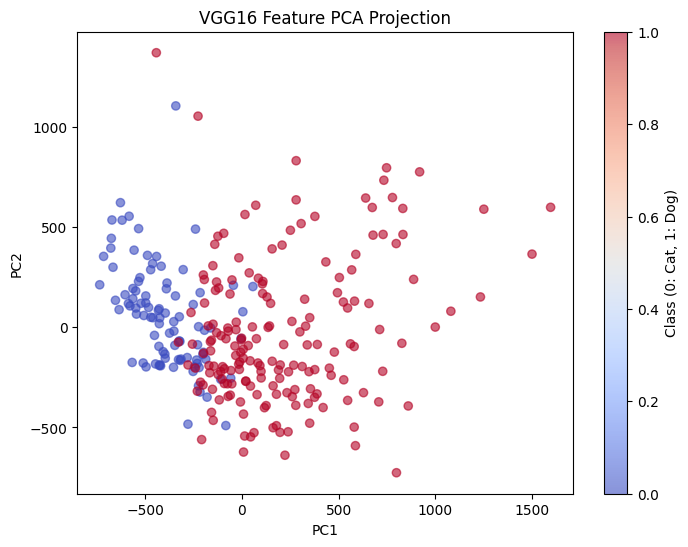

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
features_2d = pca.fit_transform(train_features_flat)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=train_labels, cmap='coolwarm', alpha=0.6)
plt.title("VGG16 Feature PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Class (0: Cat, 1: Dog)')
plt.show()


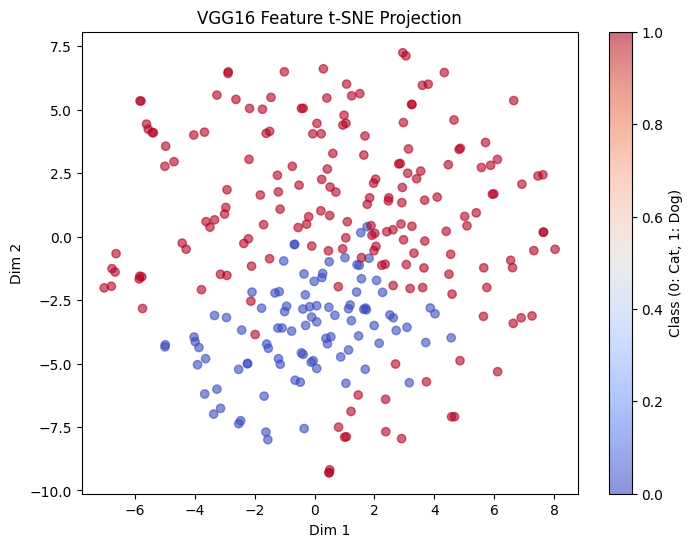

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
features_tsne = tsne.fit_transform(train_features_flat)

plt.figure(figsize=(8,6))
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=train_labels, cmap='coolwarm', alpha=0.6)
plt.title("VGG16 Feature t-SNE Projection")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label='Class (0: Cat, 1: Dog)')
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define FCNN model
fcmodel = Sequential([
    Dense(512, activation='relu', input_shape=(8192,)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification (cats vs dogs)
])

# Compile model
fcmodel.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = fcmodel.fit(
    train_features_flat, train_labels,
    epochs=20,
    batch_size=32,
    validation_data=(val_features_flat, val_labels)
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 208ms/step - accuracy: 0.5174 - loss: 14.2760 - val_accuracy: 0.7857 - val_loss: 3.0858
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7786 - loss: 4.1398 - val_accuracy: 0.8714 - val_loss: 0.8132
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8306 - loss: 3.8795 - val_accuracy: 0.9000 - val_loss: 0.6042
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8459 - loss: 2.3726 - val_accuracy: 0.9429 - val_loss: 0.8180
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8661 - loss: 2.3491 - val_accuracy: 0.9143 - val_loss: 1.1997
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9318 - loss: 0.6159 - val_accuracy: 0.9143 - val_loss: 1.2231
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9069 - loss: 0.7659 - val_accuracy: 0.9286 - val_loss: 1.0184
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9378 - loss: 0.7239 - val_accuracy: 0.9286 - val_loss: 0.89

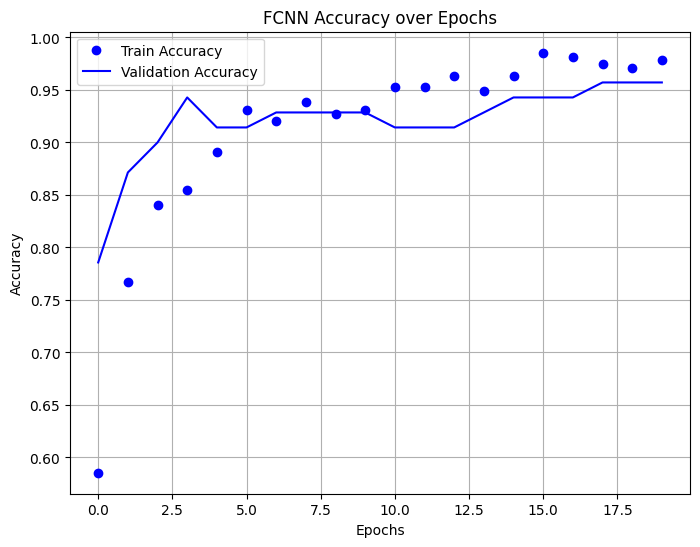

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'],'bo', label='Train Accuracy')
plt.plot(history.history['val_accuracy'],'b', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('FCNN Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()


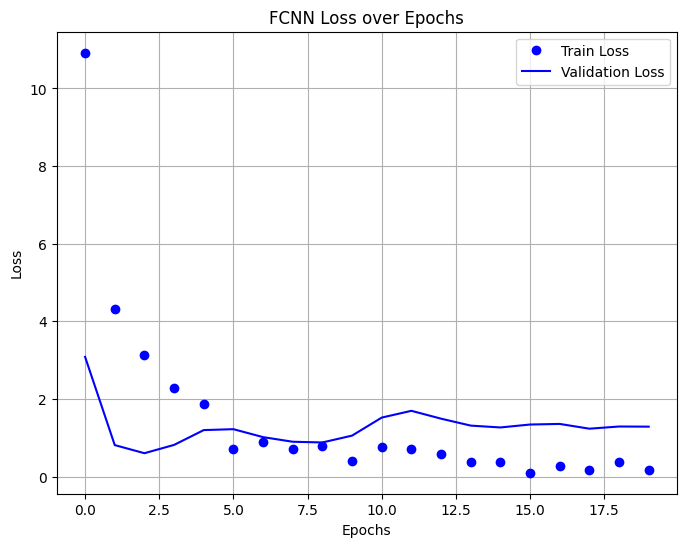

In [ ]:
import matplotlib.pyplot as plt

# Loss plot
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], 'bo',label='Train Loss')
plt.plot(history.history['val_loss'],'b', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('FCNN Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
fcmodel.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,781,829 (48.76 MB)

 Trainable params: 4,260,609 (16.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,521,220 (32.51 MB)

## Smoothing the Plots

In [ ]:
def smooth_curve(points, factor=0.8):
 smoothed_points = []
 for point in points:
  if smoothed_points:
    previous = smoothed_points[-1]
    smoothed_points.append(previous * factor + point * (1- factor))
  else:
    smoothed_points.append(point)
 return smoothed_points

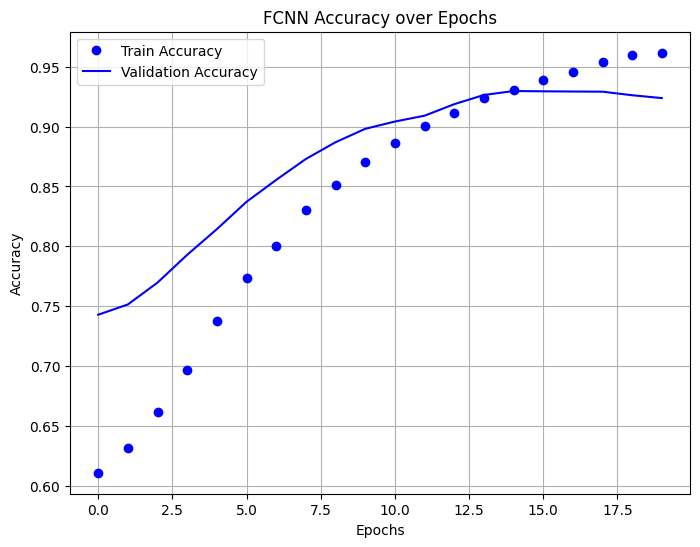

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 6))
plt.plot(smooth_curve(history.history['accuracy']),'bo', label='Train Accuracy')
plt.plot(smooth_curve(history.history['val_accuracy']),'b', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('FCNN Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

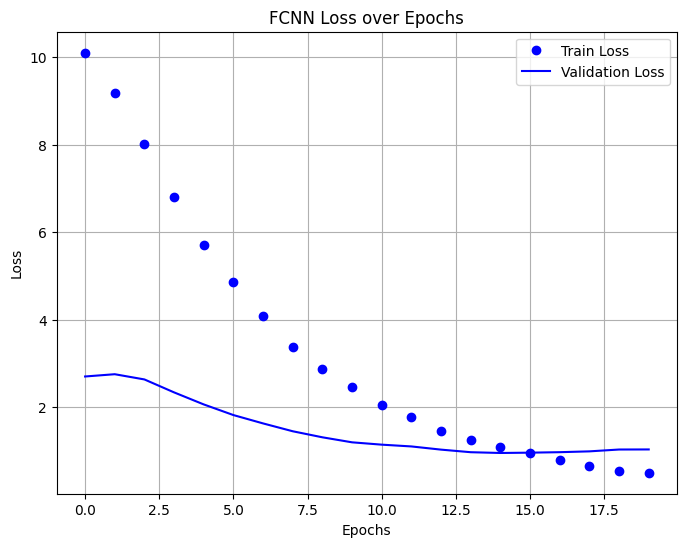

In [ ]:
import matplotlib.pyplot as plt

# Loss plot
plt.figure(figsize=(8, 6))
plt.plot(smooth_curve(history.history['loss']), 'bo',label='Train Loss')
plt.plot(smooth_curve(history.history['val_loss']),'b', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('FCNN Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Visualizing Intermediate Activations

In [ ]:
single="/content/drive/MyDrive/dataset/cats_dogs/train/cat/Bengal_109_jpg.rf.aed42b8605ef92b579992d02e2e2cc4c.jpg"

In [ ]:
from keras.preprocessing import image

In [ ]:
img = image.load_img(single, target_size=(150, 150))

In [ ]:
img_tensor = image.img_to_array(img)

In [ ]:
img_tensor = np.expand_dims(img_tensor, axis=0)

In [ ]:
img_tensor /= 255.

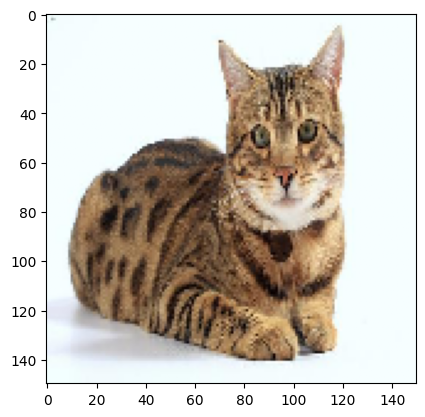

In [ ]:
plt.imshow(img_tensor[0])
plt.show()

In [ ]:
from keras import models

In [ ]:
layer_outputs = [layer.output for layer in model.layers[:8]]

In [ ]:
activation_model = models.Model(inputs=model.input, outputs=layer_outputs)

In [ ]:
activations = activation_model.predict(img_tensor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step


In [ ]:
first_layer_activation = activations[0]

In [ ]:
print(first_layer_activation.shape)

(1, 150, 150, 3)


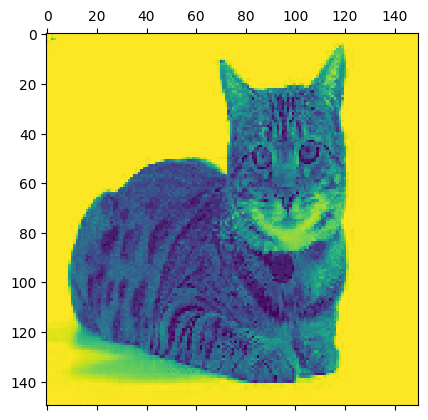

In [ ]:
plt.matshow(first_layer_activation[0, :, :, 2], cmap='viridis')

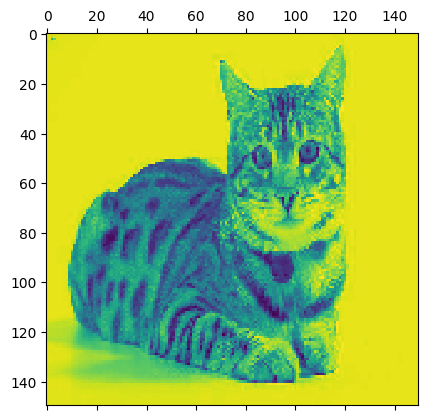

In [ ]:
plt.matshow(first_layer_activation[0, :, :, 0], cmap='viridis')

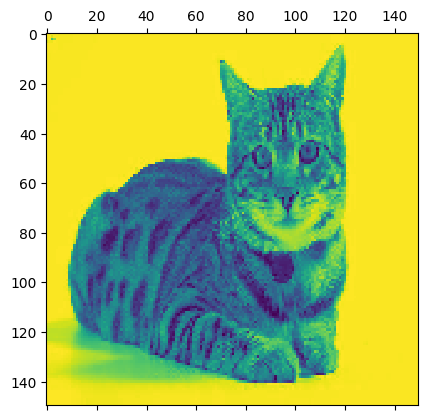

In [ ]:
plt.matshow(first_layer_activation[0, :, :, 1], cmap='viridis')